In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# '..' tells Python to go up one directory level from 'notebooks' to 'Assessment'
DATA = Path('../data')

# Updated filenames to match your directory structure exactly
train = pd.read_csv(DATA / 'train-test.csv')
validation = pd.read_csv(DATA / 'validation.csv')
template = pd.read_csv(DATA / 'validation-predictions-template.csv')
december = pd.read_csv(DATA / 'december-chart-inputs.csv')

In [8]:
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Template shape:", template.shape)
print("December shape:", december.shape)

Train shape: (48000, 14)
Validation shape: (12000, 13)
Template shape: (12000, 2)
December shape: (31, 7)


In [9]:
#understand the train dataset
train.info()
train.head()
train.describe(include="all").T
print(train.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index'

In [10]:
#understand the validation dataset
validation.info()
validation.head()  
validation.describe(include="all").T
print(validation.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  object 
 1   pickup        12000 non-null  object 
 2   delivery      12000 non-null  object 
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  object 
 9   weight        11835 non-null  float64
 10  date          12000 non-null  object 
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1.2+ MB
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']


In [13]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())
#identify the target variable in the train and validation datasets
set(train.columns) - set(validation.columns)

Train columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Validation columns:
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']


{'posted_rate'}

In [16]:
#confirm the target in the actual files
print(train["posted_rate"].describe())

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64


In [19]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
december["date"] = pd.to_datetime(december["date"])

print("Training period:")
print(train["date"].min())
print(train["date"].max())

print("\nValidation period:")
print(validation["date"].min())
print(validation["date"].max())

Training period:
2025-01-01 00:00:00
2025-10-31 00:00:00

Validation period:
2025-11-01 00:00:00
2025-12-31 00:00:00


In [21]:
print(train['date'].dt.to_period('M').value_counts().sort_index())
print(validation['date'].dt.to_period('M').value_counts().sort_index())

date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64
date
2025-11    5836
2025-12    6164
Freq: M, Name: count, dtype: int64


What we are trying to see is the range of the data in train and validation set so that we dont do a random split, and so what the task is essentially 
past data -> learn relationship -> predict future data

In [23]:
#check for missing values 
print("Missing values in train dataset:")
print(train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False))

print("Missing values in validation dataset:")
print(validation.isnull().sum()[validation.isnull().sum() > 0].sort_values(ascending=False))

Missing values in train dataset:
market_index    374
weight          300
dtype: int64
Missing values in validation dataset:
market_index    249
weight          165
dtype: int64


In [25]:
#check for the duplicates 
print("Duplicate rows in train dataset:", train["load_id"].duplicated().sum())
print("Duplicate rows in validation dataset:", validation["load_id"].duplicated().sum())

Duplicate rows in train dataset: 0
Duplicate rows in validation dataset: 0


In [28]:
#inspect the categorical variables
categorical_columns = train.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_columns)
for col in categorical_columns:
    print(f"\nValue counts for {col}:")
    print("Unique:", train[col].nunique())
    print(train[col].value_counts())

Categorical columns: ['load_id', 'pickup', 'delivery', 'equipment']

Value counts for load_id:
Unique: 48000
load_id
TR-000001    1
TR-000002    1
TR-000003    1
TR-000004    1
TR-000005    1
            ..
TR-047996    1
TR-047997    1
TR-047998    1
TR-047999    1
TR-048000    1
Name: count, Length: 48000, dtype: int64

Value counts for pickup:
Unique: 64
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
                 ... 
Detroit           337
Washington        337
St. Louis         318
Las Vegas         277
Dallas            276
Name: count, Length: 64, dtype: int64

Value counts for delivery:
Unique: 64
delivery
Lexington      1197
Fort Wayne     1176
Baton Rouge    1167
Bakersfield    1156
Hartford       1143
               ... 
St. Louis       344
Birmingham      318
Detroit         307
Dallas          306
Las Vegas       292
Name: count, Length: 64, dtype: int64

Value counts for equipment:
Unique: 3
equipmen

In [30]:
#inspect the numerical variables
numerical_columns = train.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:", numerical_columns)
train[numerical_columns].describe().T

Numerical columns: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']


,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


In [33]:
#need to check for physically impossible values in the numerical columns
print("zero weight:", (train['weight'] == 0).sum())
print("negative weight:", (train["weight"] < 0).sum())
print("zero distance:", (train['distance'] == 0).sum())
print("negative distance:", (train["distance"] < 0).sum())
print("negative posted_rate:", (train["posted_rate"] < 0).sum())
print(train.loc[train["weight"] < 0, ["weight", "posted_rate"]].head())

zero weight: 0
negative weight: 292
zero distance: 0
negative distance: 0
negative posted_rate: 0
      weight  posted_rate
68  -36559.0      2831.27
204 -26670.0      1046.92
206 -20003.0       959.15
225 -23981.0      2836.00
376 -41397.0      2522.54


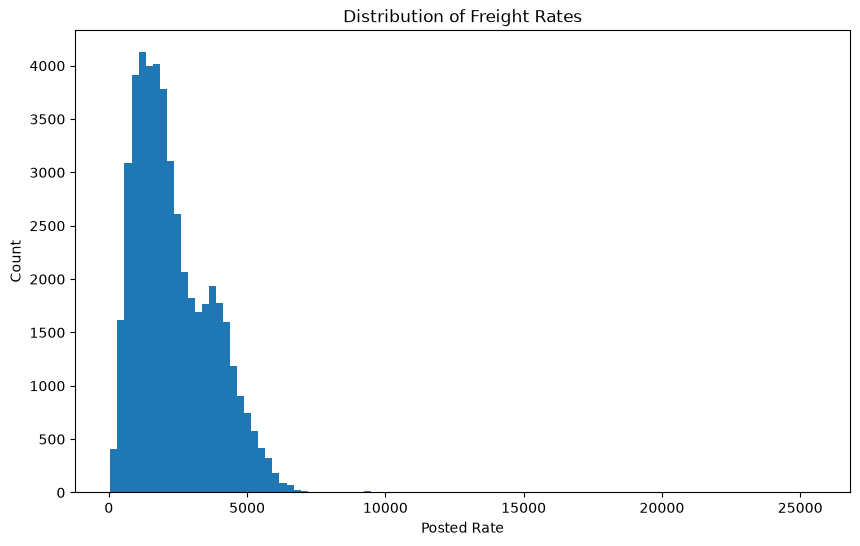

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
1%         327.168800
5%         599.738500
25%       1251.555000
50%       2030.760000
75%       3330.750000
95%       4953.766500
99%       5972.834000
max      25533.000000
Name: posted_rate, dtype: float64

In [37]:
plt.figure(figsize=(10, 6))

plt.hist(
    train["posted_rate"].dropna(),
    bins=100
)

plt.title("Distribution of Freight Rates")
plt.xlabel("Posted Rate")
plt.ylabel("Count")
plt.show()

train["posted_rate"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)


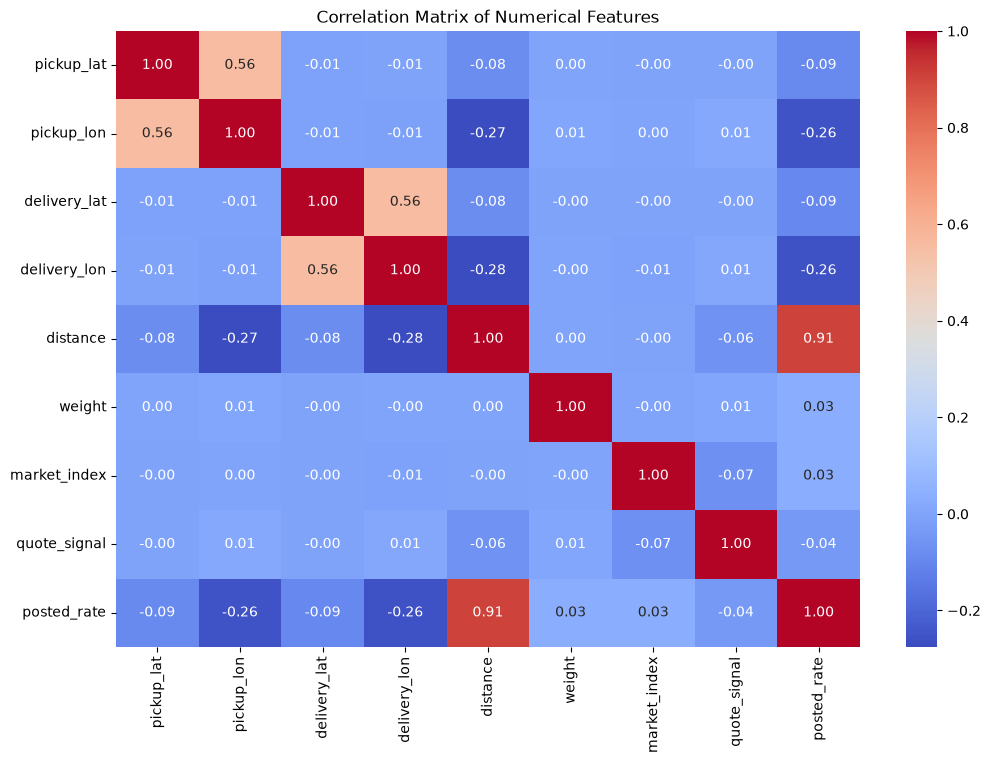

In [39]:
# strongest numerical relationships
import seaborn as sns

corr = train[numerical_columns].corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

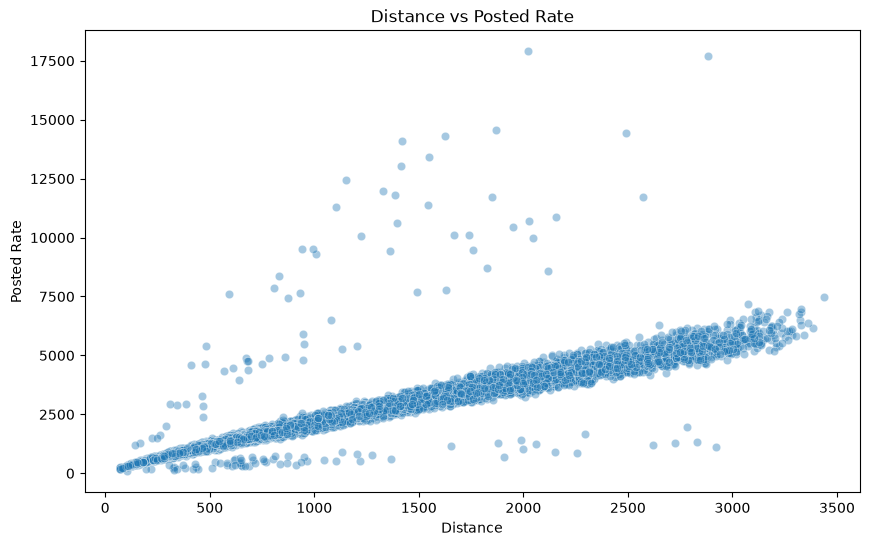

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train.sample(min(10000, len(train)), random_state=42),
    x="distance",
    y="posted_rate",
    alpha=0.4
)

plt.title("Distance vs Posted Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()

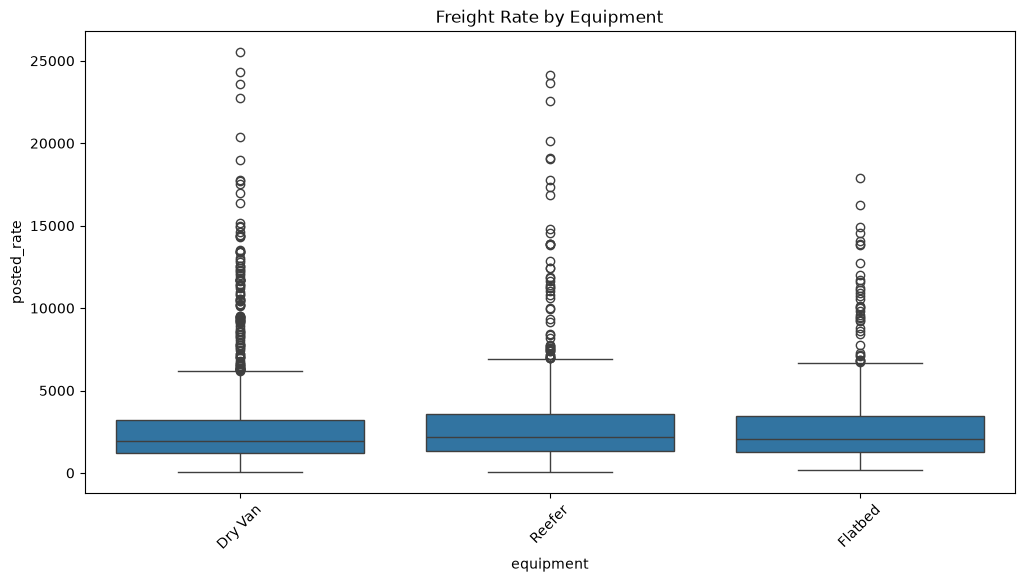

In [43]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=train,
    x="equipment",
    y="posted_rate"
)

plt.xticks(rotation=45)
plt.title("Freight Rate by Equipment")
plt.show()

In [46]:
#investigating the possible leakage
print(train.columns.tolist())
for col in train.columns:
    print(f"\nValue counts for {col}:")
    print(train[col].head())

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

Value counts for load_id:
0    TR-000001
1    TR-000002
2    TR-000003
3    TR-000004
4    TR-000005
Name: load_id, dtype: object

Value counts for pickup:
0        Richmond
1        Richmond
2    Philadelphia
3        Hartford
4          Dallas
Name: pickup, dtype: object

Value counts for delivery:
0       Baltimore
1    Philadelphia
2       Green Bay
3         Atlanta
4       Nashville
Name: delivery, dtype: object

Value counts for pickup_lat:
0    38.09122
1    38.09122
2    39.22317
3    39.55328
4    31.83025
Name: pickup_lat, dtype: float64

Value counts for pickup_lon:
0   -76.78906
1   -76.78906
2   -72.96710
3   -72.18051
4   -94.38343
Name: pickup_lon, dtype: float64

Value counts for delivery_lat:
0    38.16908
1    39.22317
2    44.30296
3    34.84933
4    35.29479
Name: delivery_lat, dtype

In [47]:
print(
    train[["market_index", "quote_signal", "posted_rate"]]
    .corr(numeric_only=True)
)

              market_index  quote_signal  posted_rate
market_index      1.000000     -0.067827     0.034165
quote_signal     -0.067827      1.000000    -0.039858
posted_rate       0.034165     -0.039858     1.000000


In [50]:
top_rates = train.nlargest(30, "posted_rate")

print(
    top_rates[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "date",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].to_string(index=False)
)

  load_id        pickup      delivery  distance equipment   weight       date  market_index  quote_signal  posted_rate
TR-012185   Bakersfield      Hartford    2829.8   Dry Van  33153.0 2025-03-19       1.16556       1.83188     25533.00
TR-037765       Phoenix      Syracuse    2810.9   Dry Van  33674.0 2025-08-27       1.04877       2.16284     24294.98
TR-001467   Los Angeles      Syracuse    2786.0    Reefer  30322.0 2025-01-10       0.98678       1.85370     24140.21
TR-017372          Reno  Philadelphia    2777.6    Reefer  33158.0 2025-04-20       1.15070       2.15601     23662.71
TR-026236    Charleston       Phoenix    2552.5   Dry Van  25665.0 2025-06-15       1.20224       1.81289     23580.42
TR-028220        Tucson       Raleigh    2423.3   Dry Van  30972.0 2025-06-27       1.32894       1.97112     22755.66
TR-003354       Phoenix    Charleston    2527.9    Reefer  36840.0 2025-01-22       1.03241       2.07342     22534.65
TR-040172    Montgomery        Fresno    2283.4 

In [51]:
print(
    train.loc[
        train["posted_rate"] > 10000,
        [
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "date",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ]
)

               pickup      delivery  distance equipment   weight       date  \
469           Phoenix  Jacksonville    2154.3   Dry Van  22509.0 2025-01-04   
1466      Los Angeles      Syracuse    2786.0    Reefer  30322.0 2025-01-10   
1949         Hartford          Reno    2794.2    Reefer  35166.0 2025-01-13   
2030           Tucson       Houston    1247.6   Dry Van  46843.0 2025-01-13   
2221           Boston  Jacksonville    1166.1   Flatbed  42165.0 2025-01-14   
...               ...           ...       ...       ...      ...        ...   
46366     Bakersfield      Columbia    2251.9   Dry Van  40729.0 2025-10-21   
46516          Toledo   Albuquerque    1684.3    Reefer  31536.0 2025-10-22   
47298          Boston   Bakersfield    2979.1    Reefer  30585.0 2025-10-27   
47536     Los Angeles      Richmond    2782.4   Dry Van  25730.0 2025-10-29   
47586  Corpus Christi     Las Vegas    1383.3   Flatbed  18645.0 2025-10-29   

       market_index  quote_signal  posted_rate  
46

In [52]:
print(
    "Rates > $10,000:",
    (train["posted_rate"] > 10000).sum()
)

print(
    "Rates > $7,500:",
    (train["posted_rate"] > 7500).sum()
)

print(
    "Rates > $5,000:",
    (train["posted_rate"] > 5000).sum()
)

Rates > $10,000: 103
Rates > $7,500: 154
Rates > $5,000: 2265


In [53]:
negative_weight = train[train["weight"] < 0].copy()

print(negative_weight.shape)

print(
    negative_weight[
        [
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "date",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].describe(include="all")
)

(292, 14)
            pickup     delivery     distance equipment        weight  \
count          292          292   292.000000       292    292.000000   
unique          64           62          NaN         3           NaN   
top     Cincinnati  Baton Rouge          NaN   Dry Van           NaN   
freq            11           10          NaN       155           NaN   
mean           NaN          NaN  1120.920205       NaN -31724.195205   
min            NaN          NaN    75.100000       NaN -47500.000000   
25%            NaN          NaN   531.975000       NaN -37284.250000   
50%            NaN          NaN   930.450000       NaN -31821.500000   
75%            NaN          NaN  1537.125000       NaN -25928.500000   
max            NaN          NaN  3161.700000       NaN  -5000.000000   
std            NaN          NaN   733.132047       NaN   8262.536326   

                                 date  market_index  quote_signal  \
count                             292    289.000000    2

In [54]:
negative_weight["abs_weight"] = negative_weight["weight"].abs()

print(
    negative_weight[
        ["weight", "abs_weight", "posted_rate"]
    ].head(20)
)

       weight  abs_weight  posted_rate
68   -36559.0     36559.0      2831.27
204  -26670.0     26670.0      1046.92
206  -20003.0     20003.0       959.15
225  -23981.0     23981.0      2836.00
376  -41397.0     41397.0      2522.54
446  -37215.0     37215.0      4841.57
495  -31214.0     31214.0      1473.78
641  -41023.0     41023.0      1264.33
806  -28320.0     28320.0      1307.76
1093 -25153.0     25153.0      1907.83
1347 -25569.0     25569.0      1529.40
1350 -33033.0     33033.0      1211.22
1529 -31309.0     31309.0      1982.49
1618 -39700.0     39700.0      1634.52
1687 -21304.0     21304.0      2414.39
1716 -19389.0     19389.0      1456.42
1835 -43143.0     43143.0       455.48
1896 -35820.0     35820.0      3312.79
1928 -31266.0     31266.0      1964.55
1939 -34419.0     34419.0      3085.22


In [56]:
train["weight_negative"] = (train["weight"] < 0).astype(int)

print(
    train.groupby("weight_negative")["posted_rate"].agg(
        ["count", "mean", "median", "std"]
    )
)

                 count         mean   median          std
weight_negative                                          
0                47708  2373.883943  2031.16  1485.511426
1                  292  2389.786233  1994.96  1641.761285


In [57]:
for col in ["weight", "market_index"]:
    print(f"\n{col}")

    missing_flag = train[col].isna()

    print(
        train.groupby(missing_flag)["posted_rate"].agg(
            ["count", "mean", "median", "std"]
        )
    )


weight
        count         mean    median          std
weight                                           
False   47700  2374.127317  2031.030  1487.087080
True      300  2350.665767  1984.995  1390.972806

market_index
              count         mean    median          std
market_index                                           
False         47626  2373.838275  2030.095  1486.906945
True            374  2392.115107  2081.100  1434.640755


In [58]:
pickup_coord_validation = (
    train.groupby("pickup")[["pickup_lat","pickup_lon"]]
    .nunique()
)
print(pickup_coord_validation)

             pickup_lat  pickup_lon
pickup                             
Albany                1           1
Albuquerque           1           1
Amarillo              1           1
Atlanta               1           1
Austin                1           1
...                 ...         ...
Tampa                 1           1
Toledo                1           1
Tucson                1           1
Tulsa                 1           1
Washington            1           1

[64 rows x 2 columns]


In [59]:
delivery_coord_variation = (
    train.groupby("delivery")
    [["delivery_lat", "delivery_lon"]]
    .nunique()
)

print(delivery_coord_variation)

             delivery_lat  delivery_lon
delivery                               
Albany                  1             1
Albuquerque             1             1
Amarillo                1             1
Atlanta                 1             1
Austin                  1             1
...                   ...           ...
Tampa                   1             1
Toledo                  1             1
Tucson                  1             1
Tulsa                   1             1
Washington              1             1

[64 rows x 2 columns]


In [60]:
for col in ["equipment"]:
    print(
        train.groupby(col)["posted_rate"].agg(
            ["count", "mean", "median", "std"]
        ).sort_values("median", ascending=False)
    )

           count         mean    median          std
equipment                                           
Reefer     12045  2553.636939  2196.670  1589.670824
Flatbed     8753  2445.087223  2076.810  1505.053087
Dry Van    27202  2271.548686  1953.035  1423.029914


In [61]:
pickup_stats = (
    train.groupby("pickup")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print(pickup_stats.head(15))
print(pickup_stats.tail(15))

                count         mean    median
pickup                                      
San Francisco     453  4071.207108  4301.810
Fresno            827  3878.910000  4160.280
Los Angeles       945  3729.638392  3996.610
Phoenix          1121  3764.774764  3935.620
Reno              642  3765.391199  3836.925
Bakersfield      1193  3519.365448  3804.880
Las Vegas         277  3292.821913  3633.060
Tucson            944  3310.996271  3535.995
Salt Lake City    394  3144.764112  3316.265
El Paso           768  3110.560078  3111.610
Albuquerque       581  2871.875439  2899.760
Providence        425  3134.073624  2603.080
Albany            811  2983.327879  2542.360
Amarillo          836  2603.807536  2502.750
Boston            603  2953.644677  2486.750
              count         mean    median
pickup                                    
Milwaukee       944  1858.548803  1594.225
Little Rock     457  1878.024114  1588.010
Harrisburg      574  2181.892700  1573.530
Birmingham      364 

In [62]:
delivery_stats = (
    train.groupby("delivery")["posted_rate"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

print(delivery_stats.head(15))
print(delivery_stats.tail(15))

                count         mean    median
delivery                                    
San Francisco     467  4064.472998  4356.600
Fresno            763  3865.377156  4140.170
Los Angeles       955  3742.250932  4046.090
Phoenix          1090  3751.473110  3921.980
Reno              653  3679.871639  3783.880
Bakersfield      1156  3532.198893  3742.535
Las Vegas         292  3428.375274  3707.765
Tucson            997  3363.189789  3591.790
Salt Lake City    406  3164.350788  3316.060
El Paso           769  3008.979779  3089.550
Albuquerque       572  2962.709720  2931.230
Boston            619  2998.409370  2570.380
Albany            812  2967.729901  2559.395
Amarillo          850  2651.613612  2557.745
Providence        415  2940.196048  2522.540
              count         mean    median
delivery                                  
Charleston      851  2110.727697  1605.320
Savannah        528  2009.483030  1597.450
Birmingham      318  1818.255660  1592.400
Memphis         912 

         count         mean    median          std
month                                             
2025-01   4918  2255.967048  1915.200  1454.274952
2025-02   4337  2273.804801  1994.250  1317.077105
2025-03   5036  2372.268092  2022.920  1462.531615
2025-04   4819  2372.162308  2044.240  1463.102457
2025-05   4913  2421.776342  2065.510  1486.071436
2025-06   4783  2497.030115  2120.220  1606.707302
2025-07   4912  2415.162030  2059.145  1504.943296
2025-08   4759  2338.407661  2015.730  1474.979672
2025-09   4670  2406.374013  2057.130  1523.483983
2025-10   4853  2379.051374  2035.900  1528.714038


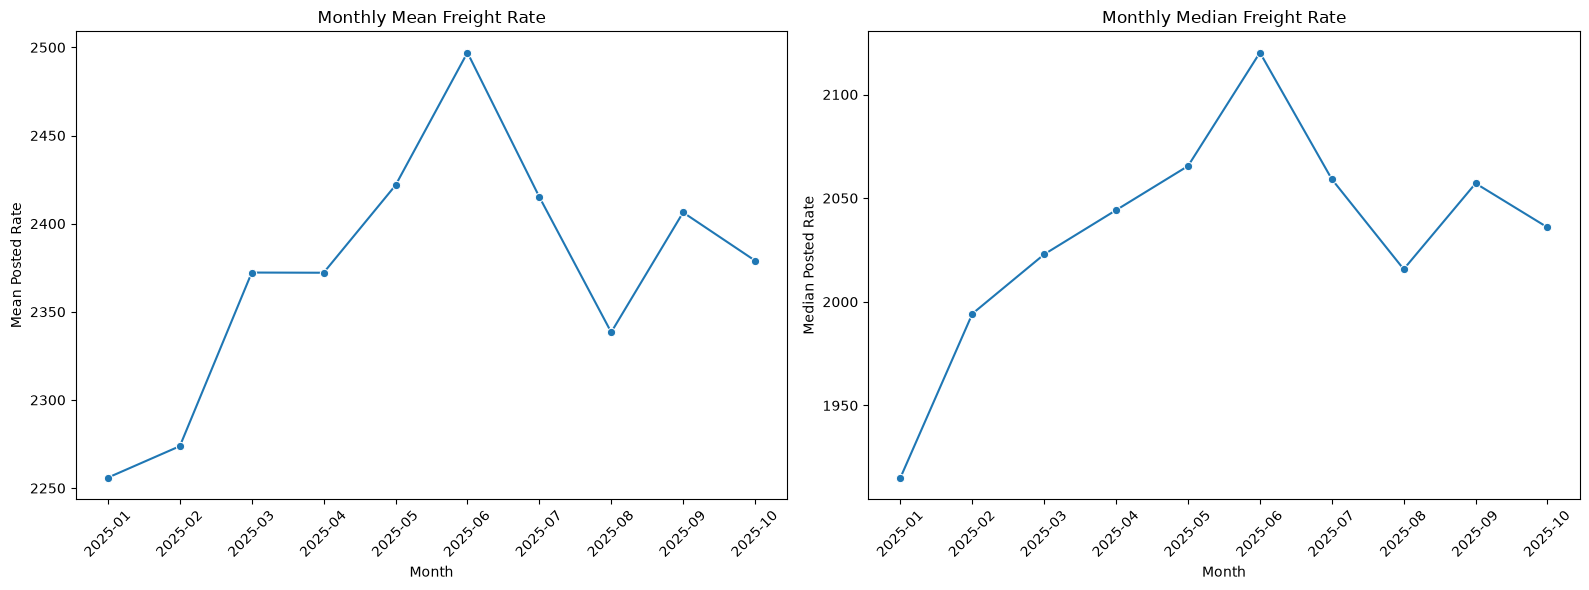

In [65]:
train["month"] = train["date"].dt.to_period("M")

monthly_stats = (
    train.groupby("month")["posted_rate"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
)

print(monthly_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(
    data=monthly_stats,
    x=monthly_stats.index.astype(str),
    y="mean",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Monthly Mean Freight Rate")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean Posted Rate")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_stats,
    x=monthly_stats.index.astype(str),
    y="median",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Monthly Median Freight Rate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Median Posted Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [66]:
import numpy as np
import pandas as pd

train["log_rate_per_mile"] = np.log1p(train["posted_rate"]) - np.log1p(train["distance"])

monthly_corr = (
    train.groupby(train["date"].dt.to_period("M"))
    .apply(lambda g: g["quote_signal"].corr(g["log_rate_per_mile"]))
)

print(monthly_corr)

validation["log_distance"] = np.log1p(validation["distance"])

print(
    validation[["quote_signal", "distance"]]
    .corr()
)

print("TRAIN")
print(train["quote_signal"].describe())

print("\nVALIDATION")
print(validation["quote_signal"].describe())

train["month"] = train["date"].dt.to_period("M")

print(
    train.groupby("month")["quote_signal"]
    .agg(["mean", "median", "std", "min", "max"])
)

date
2025-01    0.585728
2025-02    0.618917
2025-03    0.624871
2025-04   -0.586476
2025-05   -0.594765
2025-06    0.634504
2025-07   -0.608590
2025-08   -0.009624
2025-09    0.635238
2025-10   -0.561406
Freq: M, dtype: float64
              quote_signal  distance
quote_signal      1.000000  0.011362
distance          0.011362  1.000000
TRAIN
count    48000.000000
mean         2.062468
std          0.291391
min          0.692280
25%          1.891030
50%          2.055750
75%          2.221685
max          3.610350
Name: quote_signal, dtype: float64

VALIDATION
count    12000.000000
mean         2.051334
std          0.219804
min          1.234760
25%          1.903467
50%          2.051230
75%          2.200030
max          2.896350
Name: quote_signal, dtype: float64
             mean    median       std      min      max
month                                                  
2025-01  2.068436  2.028715  0.250335  1.56417  3.36465
2025-02  2.097130  2.060400  0.251679  1.57710  3.19

In [68]:
train["log_rate"] = np.log(train["posted_rate"])

median = train["log_rate"].median()
mad = np.median(np.abs(train["log_rate"] - median))

train["mad_score"] = (
    np.abs(train["log_rate"] - median) / mad
)

suspects = train[train["mad_score"] > 6].copy()

print("Suspects:", len(suspects))

print(
    suspects[
        [
            "load_id",
            "pickup",
            "delivery",
            "distance",
            "equipment",
            "weight",
            "market_index",
            "posted_rate"
        ]
    ].sort_values("posted_rate").head(30)
)
train["rate_per_mile"] = train["posted_rate"] / train["distance"]

print(
    train["rate_per_mile"].describe(
        percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
    )
)
print(
    suspects["rate_per_mile"].describe()
)

Suspects: 11
         load_id        pickup     delivery  distance equipment   weight  \
5961   TR-005962  Grand Rapids    Green Bay     105.5   Dry Van  24598.0   
30705  TR-030706      Hartford     New York     114.4   Dry Van  25901.0   
14990  TR-014991   Los Angeles      Phoenix      93.9    Reefer  32284.0   
872    TR-000873    Cincinnati    Lexington     144.0   Dry Van  13535.0   
4674   TR-004675      Hartford    Baltimore     149.3    Reefer  27506.0   
9137   TR-009138    Fort Wayne       Toledo     105.0    Reefer  35124.0   
34343  TR-034344    Louisville   Cincinnati      70.0   Dry Van  35673.0   
10959  TR-010960       Lubbock  San Antonio     122.6    Reefer  42648.0   
18954  TR-018955    Cincinnati    St. Louis     228.7   Dry Van  25262.0   
11236  TR-011237      Columbia    Lexington     228.3   Dry Van  22221.0   
47742  TR-047743       Atlanta    Nashville     136.8    Reefer  35204.0   

       market_index  posted_rate  
5961        1.02929        57.22  
3070

KeyError: 'rate_per_mile'

In [69]:
train["log_rate"] = np.log(train["posted_rate"])

print(
    train[
        ["market_index", "log_rate"]
    ].corr()
)

              market_index  log_rate
market_index      1.000000  0.030855
log_rate          0.030855  1.000000
